#Projeto Series Temporais

  - Aluna: Maria Eduarda Neves
  - Email: meen@cin.ufpe.br

#Descrição do Problema

O conjunto de dados apresentado foi coletado através da base de dados da APAC (Agência Pernambucana de Águas e Climas) trazendo informações referentes ao Monitoramento Pluviométrico em um dado intervalo de tempo
  - Link de apoio: http://old.apac.pe.gov.br/meteorologia/monitoramento-pluvio.php#
  - Mesoregião: Metropolitana do Recife
  - Posto: Recife (Várzea)

#Download das Bibliotecas

In [ ]:
!pip install tensorflow

In [ ]:
import pandas as pd
import numpy as np
import copy
import itertools
import random
import os

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.tsa.api as tsa
import torch
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.tools import diff
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.arima.model import ARIMA


import tensorflow as tf

from tensorflow import keras


from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LSTM
from sklearn.neural_network import MLPRegressor
from tensorflow.keras.metrics import MeanSquaredError

from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import make_classification
from statsmodels.tools.eval_measures import rmse
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

- Será utilizado o seeding para todos os geradores de números pseudo-aleatórios e permitir a reprodutibilidade do projeto

In [ ]:
def set_seed(seed):
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Leave as True to ensure determinism. Some operations may crash
    torch.use_deterministic_algorithms(False)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

#Carregamento e Pré-Processamento da base de dados

##Carregamento do banco de dados

- O carregamento da base de dados é feito através de um link do GitHub, onde a base de dados foi salva em formato .csv
- Em seguida, o carregamento se da através da biblioteca Pandas, onde é possível obter um DataFrame para o conjunto de dados

In [ ]:
url = 'https://raw.githubusercontent.com/meduardaeneves/meduardaeneves.github.io/master/files/personal_projects_data_pt/times_series_rainfall/download_pluv_recife.xlsx'

In [ ]:
df_pluv = pd.read_excel(url)

In [ ]:
df_pluv.replace('-',np.nan,inplace=True)

<ipython-input-13-fa8e6756426d>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_pluv.replace('-',np.nan,inplace=True)


In [ ]:
df_pluv

,ódigo,Posto,Ano,Janeiro,Fevereiro,Março,Abril,Maio,Junho,Julho,Agosto,Setembro,Outubro,Novembro,Dezembro
0,30,Recife (Várzea),1970,101.4,95.8,252.7,592.4,190.0,367.3,504.5,311.3,76.2,11.9,29.5,33.6
1,30,Recife (Várzea),1971,64.5,40.8,166.0,186.6,521.7,277.2,414.0,154.9,170.1,145.9,42.8,11.4
2,30,Recife (Várzea),1972,40.0,61.5,157.3,359.4,287.9,337.1,239.0,329.6,127.9,72.3,8.9,39.9
3,30,Recife (Várzea),1973,40.8,109.5,200.3,771.4,313.0,585.6,422.6,100.9,200.4,118.7,23.7,65.6
4,30,Recife (Várzea),1974,205.9,174.5,323.5,285.3,454.6,388.3,314.4,124.4,136.5,14.7,15.1,86.3
5,30,Recife (Várzea),1975,87.1,53.0,259.9,110.6,327.6,406.6,494.3,173.3,73.3,17.0,34.2,134.5
6,30,Recife (Várzea),1976,47.2,255.4,406.2,237.2,299.4,293.4,268.5,61.1,29.2,148.6,48.5,129.8
7,30,Recife (Várzea),1977,74.7,137.8,182.1,223.1,295.4,425.7,542.9,133.4,95.6,109.4,19.7,91.2
8,30,Recife (Várzea),1978,36.0,234.2,283.7,446.4,260.9,300.2,505.8,210.8,291.3,46.6,56.4,69.2
9,30,Recife (Várzea),1979,79.2,148.6,207.9,156.5,313.8,410.7,230.1,131.7,252.9,39.6,65.2,NaN


##Pré-Processamento da base de dados

- Observa-se que há um salto no tempo entre 1985 e 1993.
- Sendo assim, vamos considerar os valores, no futuro, somente a partir de 1994
- Por enquanto, tem-se como prioridade converter a tabela de forma que exista somente uma coluna de data, com os meses se alocando um após o outro. Sendo assim, será obtida somente uma coluna de data e uma coluna de dados, contendo os valores referentes à precipitação da chuva

In [ ]:
df_pluv_mod = pd.DataFrame(columns=['ano','mes_valor','date','mes_text','value'],)

In [ ]:
columns_mes = ['Janeiro','Fevereiro','Março','Abril','Maio','Junho','Julho','Agosto','Setembro','Outubro','Novembro','Dezembro']

In [ ]:
for index, row in df_pluv.iterrows():
    ano = row['Ano']
    mes_valor = ''
    for i,mes in enumerate(columns_mes):
      i_str = str(i+1)
      if len(i_str) == 1:
        mes_valor = '0'+i_str
      else:
        mes_valor = i_str
      date = f'{ano}-{mes_valor}'
      dado_pluv_mes = row[mes]
      df_pluv_mod.loc[len(df_pluv_mod)] = [ano,mes_valor,date,mes,dado_pluv_mes]

In [ ]:
df_pluv_mod

,ano,mes_valor,date,mes_text,value
0,1970,01,1970-01,Janeiro,101.4
1,1970,02,1970-02,Fevereiro,95.8
2,1970,03,1970-03,Março,252.7
3,1970,04,1970-04,Abril,592.4
4,1970,05,1970-05,Maio,190.0
...,...,...,...,...,...
535,2021,08,2021-08,Agosto,309.0
536,2021,09,2021-09,Setembro,50.8
537,2021,10,2021-10,Outubro,42.8
538,2021,11,2021-11,Novembro,8.6


In [ ]:
df_pluv_st = copy.deepcopy(df_pluv_mod)
df_pluv_st = df_pluv_st.drop(columns=(['ano','mes_valor','mes_text']))

- Abaixo, tem a representação do banco de dados que será utilizado para todo o processo de análise da série temporal

In [ ]:
df_pluv_st

,date,value
0,1970-01,101.4
1,1970-02,95.8
2,1970-03,252.7
3,1970-04,592.4
4,1970-05,190.0
...,...,...
535,2021-08,309.0
536,2021-09,50.8
537,2021-10,42.8
538,2021-11,8.6


- É possível, através do gráfico abaixo, ver a representação dos dados ao lonto do tempo

In [ ]:
def time_series_plot(df,x_colum,y_colum,title):
  fig = px.line(df,x=x_colum,y=y_colum,title=title)
  fig.show()

In [ ]:
time_series_plot(df_pluv_st,'date','value','Dados pluviométricos ao longo dos anos na cidade do Recife')

- Fazendo agora o ajuste no dataframe, pegando apenas dados a partir de 1994

In [ ]:
df_pluv_st['date'] = pd.to_datetime(df_pluv_st['date'])

In [ ]:
df_pluv_st_filt = df_pluv_st[df_pluv_st['date'] >= '1994-01']

In [ ]:
df_pluv_st_filt['date'] = df_pluv_st_filt['date'].astype(str)

<ipython-input-25-2a2c1d5f0e53>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



- Em seguida, é feita uma análise para observar se existe algum valor nulo, caso sim, será feita a substituição dele utilizando `ffill`

In [ ]:
df_pluv_st_filt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 336 entries, 204 to 539
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    336 non-null    object 
 1   value   335 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.9+ KB


In [ ]:
if df_pluv_st_filt['value'].isnull().values.any() == True:
    df_pluv_st_filt['value'] = df_pluv_st_filt['value'].ffill()

<ipython-input-27-dc4c23fb4ffc>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
df_pluv_st_filt['final_date'] = df_pluv_st_filt['date']

<ipython-input-28-f466d8637aa3>:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
df_pluv_st_filt = df_pluv_st_filt.set_index('date')

In [ ]:
time_series_plot(df_pluv_st_filt,'final_date','value','Dados pluviométricos ao longo dos anos na cidade do Recife')

###Modificação dos valores pluviométricos para preparação para utilizá-los nos modelos (adição de log e remoção de sazonalidade)

- Utilização de log nos valores pluviométricos para reduzir assimetria dos dados

In [ ]:
df_pluv_st_filt['log_value'] = np.log(df_pluv_st_filt['value'])

In [ ]:
time_series_plot(df_pluv_st_filt,'final_date','log_value','Dados pluviométricos ao longo dos anos na cidade do Recife')

- Decomposição dos valores para remover a sazonalidade existente
  - Devido ao fato dos dados serem apresentados a cada mês, será utilizado um período de 12.

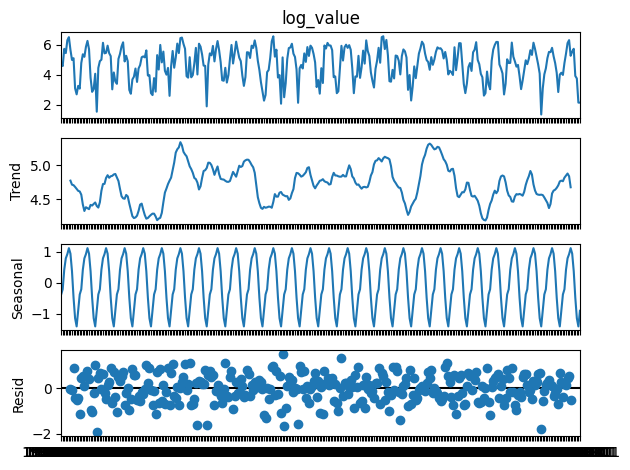

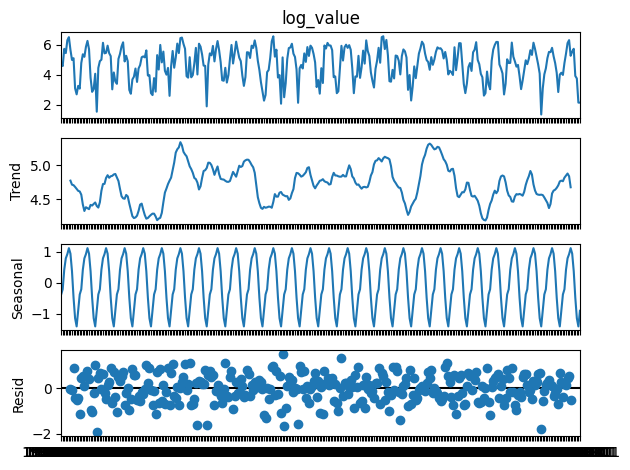

In [ ]:
df_decomp = tsa.seasonal_decompose(df_pluv_st_filt['log_value'], period=12)
df_decomp.plot()

In [ ]:
df_pluv_st_filt['sazonalidade'] = df_decomp.seasonal

In [ ]:
df_pluv_st_filt['value_desaz'] = df_pluv_st_filt['log_value']/df_pluv_st_filt['sazonalidade']

In [ ]:
time_series_plot(df_pluv_st_filt,'final_date','value_desaz','Dados pluviométricos ao longo dos anos na cidade do Recife')

- Observa-se que ainda existe uma possível sazonalidade dos dados. Sendo assim, o processo de retirada da sazonalidade será feito novamente

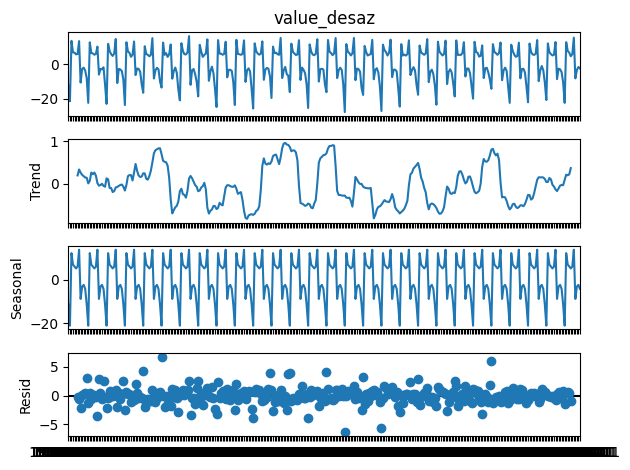

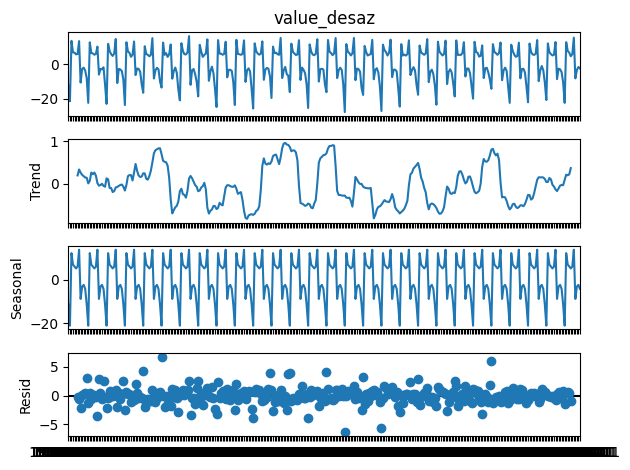

In [ ]:
df_decomp2 = tsa.seasonal_decompose(df_pluv_st_filt['value_desaz'], period=12)
df_decomp2.plot()

In [ ]:
df_pluv_st_filt['sazonalidade2'] = df_decomp2.seasonal
df_pluv_st_filt['value_desaz2'] = df_pluv_st_filt['value_desaz']/df_pluv_st_filt['sazonalidade2']

In [ ]:
time_series_plot(df_pluv_st_filt,'final_date','value_desaz2','Dados pluviométricos ao longo dos anos na cidade do Recife')

###Normalização dos dados

- Os modelos de séries temporais que serão utilizados exigem uma normalização dos dados
- Neste caso, a normalização será feita através do MAX - MIN, onde serão extraídos os valores máximos e mínimos e os demais valores vão ser balizados por eles

In [ ]:
def normalizar_colunas(coluna_df,max,min):
  coluna_df_norm = (coluna_df-min)/(max-min)
  return coluna_df_norm

In [ ]:
def desnormalizar_colunas(coluna_df,max,min):
  coluna_df_desnorm = coluna_df*(max-min) + min
  return coluna_df_desnorm

In [ ]:
data_to_frame = df_pluv_st_filt['value_desaz2'].to_frame()

In [ ]:
max_value = data_to_frame.max().values[0]
min_value = data_to_frame.min().values[0]

print(f'Valor Máximo de treinamento: {max_value}')
print(f'Valor Mínimo de treinamento: {min_value}')

Valor Máximo de treinamento: 1.4144398379902037
Valor Mínimo de treinamento: 0.41026452097030097


In [ ]:
df_pluv_st_filt['value_norm'] = normalizar_colunas(df_pluv_st_filt['value_desaz2'],max_value,min_value)

In [ ]:
time_series_plot(df_pluv_st_filt,'final_date','value_norm','Dados pluviométricos ao longo dos anos na cidade do Recife')

#Modelos de Séries Temporais

##Modelo ARIMA (Modelo 01)

- O modelo ARIMA vai buscar estimar pesos para valores passados de uma série temporal
- Para o modelo ARIMA vamos precisar de três parâmetros:
  - P: Parâmetro autoregressivo
  - D: Parâmetros relacionando quantas diferenciações eu preciso realizar para que a série temporal torne-se estacionária
  - Q: Parâmetros de médias móveis
- Para a identificação dos parâmetros a serem utilizados vamos utilizar a metodologia de Box & Jenkins

###Separação dos dados em treinamento, validação e teste

- Os dados utilizados para a modelagem da série temporal vão seguir o seguinte padrão:
  - Treinamento: 50 %;
  - Validação: 25 %;
  - Teste: 25 %;

In [ ]:
value_to_split = df_pluv_st_filt['value_norm']

In [ ]:
value_to_split

,value_norm
date,
1994-01-01,0.677698
1994-02-01,0.607581
1994-03-01,0.700185
1994-04-01,0.573938
1994-05-01,0.699747
...,...
2021-08-01,0.711174
2021-09-01,0.519328
2021-10-01,0.652455


In [ ]:
test_split = 0.25
train_val_split = (1-test_split)

val_split_split = 0.25

val_split_final = val_split_split/train_val_split

In [ ]:
train_initial_fluv, test_fluv = train_test_split(value_to_split, test_size=test_split, shuffle=False)
train_fluv, validation_fluv = train_test_split(train_initial_fluv, test_size=val_split_final, shuffle=False)

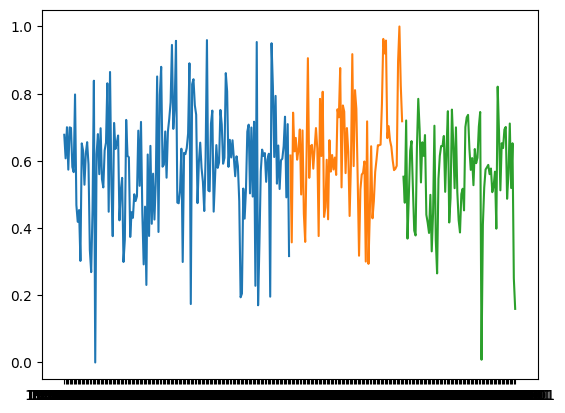

In [ ]:
plt.plot(train_fluv); plt.plot(validation_fluv); plt.plot(test_fluv)

###Análise dos Parâmetros do Modelo ARIMA

####Parâmetro D

  - Nele analisamos a diferença do conjunto de treinamento
  - diff --> observação posterior menos a anterior
  - Precisamos diferenciar para analisar se a série está ou não estacionária
  - O ideal é que a série não esteja variando com o tempo

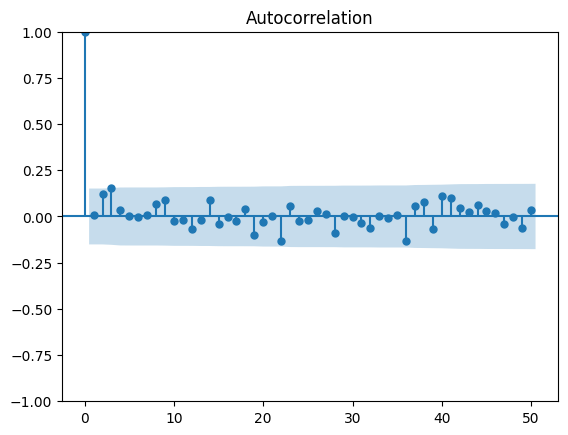

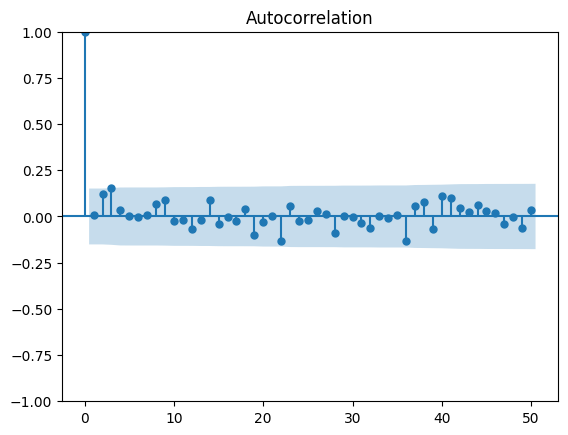

In [ ]:
sm.graphics.tsa.plot_acf(train_fluv, lags=50)

- Será utilizado o `adfuller` para analisar se o conjunto de treinamento é ou não estacionário.

In [ ]:
print('Precipitação Pluviométrica')
result_est_fluv = adfuller(train_fluv)
print('ADF Statistic:', result_est_fluv[0])
print('p-value:', result_est_fluv[1])
if result_est_fluv[1] > 0.05:
    print("A série não é estacionária. Será necessário diferenciar os dados.")

Precipitação Pluviométrica
ADF Statistic: -5.743221264517237
p-value: 6.206047840863632e-07


- Como o p-value foi maior que 0.05, a série aparenta ser estacionária, não sendo necessário diferenciar os dados

<Axes: xlabel='date'>

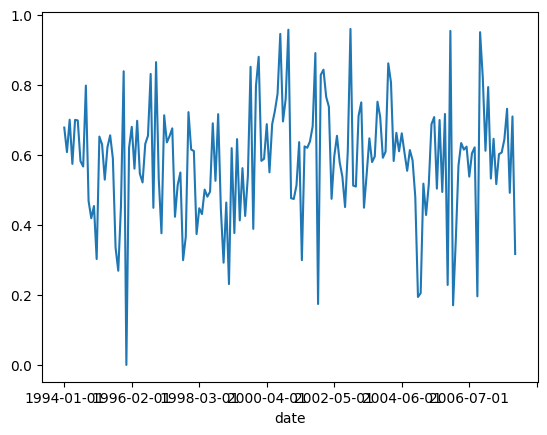

In [ ]:
train_fluv.plot()

<Axes: xlabel='date'>

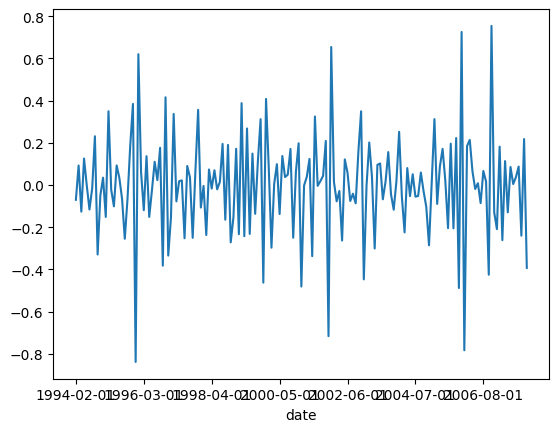

In [ ]:
df_pop_dessazon_diff1 = diff(train_fluv,1)
df_pop_dessazon_diff1.plot()

In [ ]:
param_d = [0]

####Parâmetro Q

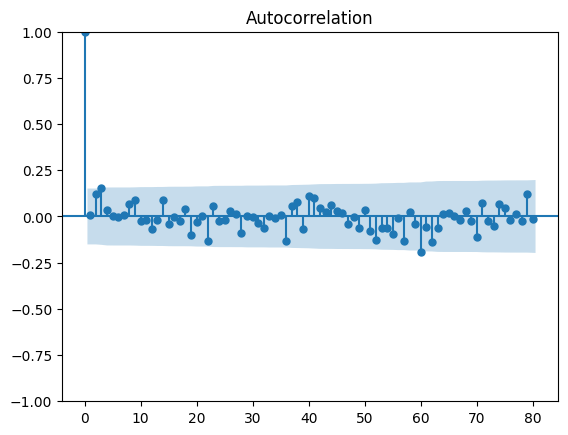

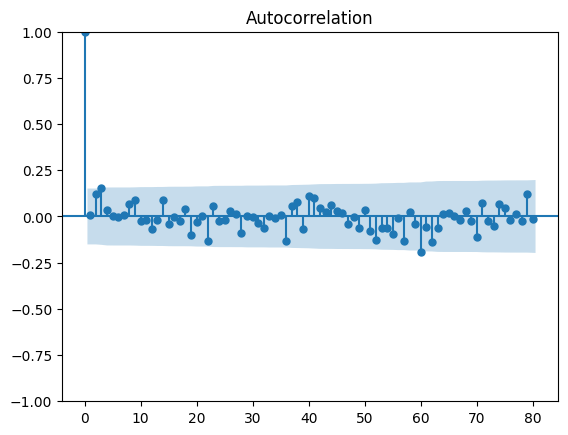

In [ ]:
sm.graphics.tsa.plot_acf(train_fluv, lags=80)

In [ ]:
param_q = [0,1,2,3]

####Parâmetro P

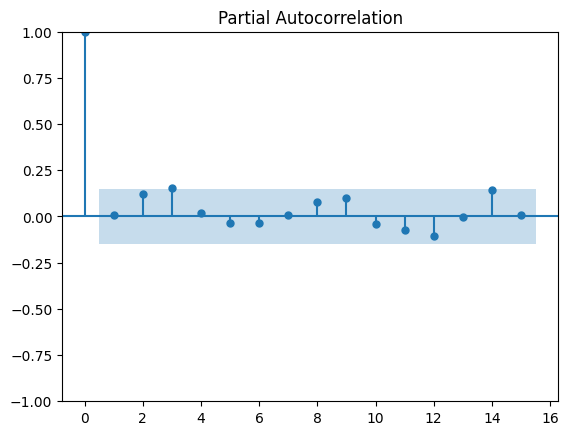

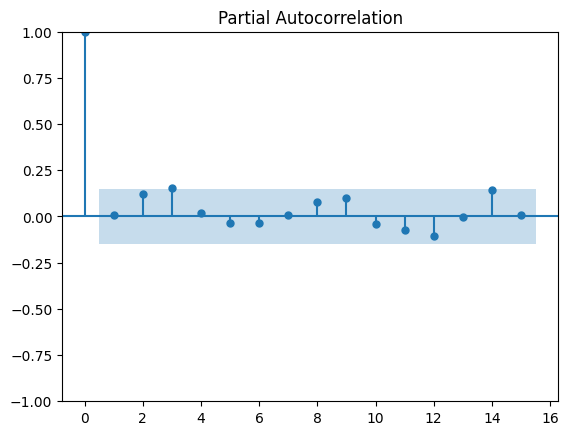

In [ ]:
sm.graphics.tsa.plot_pacf(train_fluv, lags=15)

In [ ]:
param_p = [0,1,2,3]

In [ ]:
pdq_param = list(itertools.product(param_p,param_d,param_q))
print(pdq_param)

[(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 0, 3), (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 0, 3), (3, 0, 0), (3, 0, 1), (3, 0, 2), (3, 0, 3)]


###Aplicação do modelo ARIMA

- Para a aplicação do modelo ARIMA será utilizada a metodologia de Box & Jenkins
  - O teste Jarque-bera será responsável por isso, ele vai analisar se os dados seguem uma distribuição normal
  - Será analisado o p-value:
    - h0 --> Hipótese nula --> dados apresentam distribuição normal (p-value > 0.05)
    - h1 --> hipótese não-nula --> dados não apresentam distribuição normal

In [ ]:
def model_fit_jarque_bera(model,p,q,d,df_results_initial):

  est_jarque_bera = model[0]
  p_value = model[1]
  assimetria = model[2]
  curtose = model[3]

  print('Estatística Jarque-Bera :', est_jarque_bera)
  print('P-valor :', p_value)
  print('Assimetria :', assimetria)
  print('Curtose :',curtose,'\n')

  df_results_initial.loc[len(df_results_initial)] = [f'({p},{q},{d})',est_jarque_bera,p_value,assimetria,curtose]
  return df_results_initial

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
arima_param_df = pd.DataFrame(columns=['arima_param','est_jarque_bera','p_valor','assimetria','curtose'])
arima_param_df

,arima_param,est_jarque_bera,p_valor,assimetria,curtose


In [ ]:
warnings.filterwarnings("ignore", message="No frequency information was provided, so inferred frequency MS will be used.")
warnings.filterwarnings("ignore", message="Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.")
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found. Using zeros as starting parameters.")

In [ ]:
for param_exist in pdq_param:
  arima_model_jq = ARIMA(train_fluv, order=(param_exist[0], param_exist[1], param_exist[2]))
  arima_model_jq_fit = arima_model_jq.fit()

  print(f'ARIMA, param {param_exist}; AIC: {arima_model_jq_fit.aic:.2f}; BIC: {arima_model_jq_fit.bic}; HQIC: {arima_model_jq_fit.hqic}')
  arima_model_jq_resid = jarque_bera(arima_model_jq_fit.resid)

  arima_param_df = model_fit_jarque_bera(arima_model_jq_resid,param_exist[0], param_exist[1], param_exist[2],arima_param_df)

ARIMA, param (0, 0, 0); AIC: -114.58; BIC: -108.32965149661413; HQIC: -112.04186603850466
Estatística Jarque-Bera : 6.593055942255753
P-valor : 0.03701144939387381
Assimetria : -0.3878527153943974
Curtose : 3.583220557981914 

ARIMA, param (0, 0, 1); AIC: -112.59; BIC: -103.21849179944216; HQIC: -108.78681361227797
Estatística Jarque-Bera : 6.758606644568678
P-valor : 0.03407118310214063
Assimetria : -0.38982390088015945
Curtose : 3.598050616711232 

ARIMA, param (0, 0, 2); AIC: -113.04; BIC: -100.54316752106337; HQIC: -107.96759660484445
Estatística Jarque-Bera : 4.583064405726516
P-valor : 0.10111141989927425
Assimetria : -0.3256577801322641
Curtose : 3.480116160412939 

ARIMA, param (0, 0, 3); AIC: -115.85; BIC: -100.23485504198456; HQIC: -109.51539139671092
Estatística Jarque-Bera : 3.2335024605164744
P-valor : 0.19854267188240232
Assimetria : -0.3080835432954414
Curtose : 3.28682232188766 

ARIMA, param (1, 0, 0); AIC: -112.59; BIC: -103.22158123380244; HQIC: -108.78990304663824
E

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [ ]:
arima_param_df

,arima_param,est_jarque_bera,p_valor,assimetria,curtose
0,"(0,0,0)",6.593056,0.037011,-0.387853,3.583221
1,"(0,0,1)",6.758607,0.034071,-0.389824,3.598051
2,"(0,0,2)",4.583064,0.101111,-0.325658,3.480116
3,"(0,0,3)",3.233502,0.198543,-0.308084,3.286822
4,"(1,0,0)",6.799142,0.033388,-0.390276,3.601702
5,"(1,0,1)",6.542684,0.037955,-0.377805,3.603094
6,"(1,0,2)",3.445569,0.178568,-0.309583,3.329936
7,"(1,0,3)",3.065929,0.215895,-0.301752,3.271613
8,"(2,0,0)",5.003056,0.081960,-0.334395,3.517148
9,"(2,0,1)",4.019551,0.134019,-0.328841,3.376398


- Observa-se que alguns parâmetros do modelo ARIMA confirmaram a hipótese h0
- Escolheu-se dois modelos arima para analisar os dados:
  - Modelo 1: com parâmetros ARIMA que apresentaram p-value mais próximo de 0.05
  - Modelo 2: com parâmetros ARIMA que apresentaram p-value mais distantes de 0.05

In [ ]:
arim_param_chosen1 = (0,0,2)
arim_param_chosen2 = (2,0,2)

In [ ]:
arima_final_model1 = ARIMA(train_fluv, order=arim_param_chosen1)
arima_final_model1_fit = arima_final_model1.fit()

In [ ]:
arima_final_model2 = ARIMA(train_fluv, order=arim_param_chosen2)
arima_final_model2_fit = arima_final_model2.fit()

In [ ]:
print(arima_final_model1_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             value_norm   No. Observations:                  168
Model:                 ARIMA(0, 0, 2)   Log Likelihood                  60.520
Date:                Sat, 18 Jan 2025   AIC                           -113.039
Time:                        06:06:08   BIC                           -100.543
Sample:                    01-01-1994   HQIC                          -107.968
                         - 12-01-2007                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5844      0.015     39.596      0.000       0.555       0.613
ma.L1         -0.0281      0.065     -0.430      0.668      -0.156       0.100
ma.L2          0.1225      0.076      1.616      0.1

In [ ]:
print(arima_final_model2_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             value_norm   No. Observations:                  168
Model:                 ARIMA(2, 0, 2)   Log Likelihood                  66.920
Date:                Sat, 18 Jan 2025   AIC                           -121.840
Time:                        06:06:08   BIC                           -103.096
Sample:                    01-01-1994   HQIC                          -114.233
                         - 12-01-2007                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5842      0.015     38.101      0.000       0.554       0.614
ar.L1          0.7500      0.078      9.676      0.000       0.598       0.902
ar.L2         -0.7141      0.090     -7.897      0.0

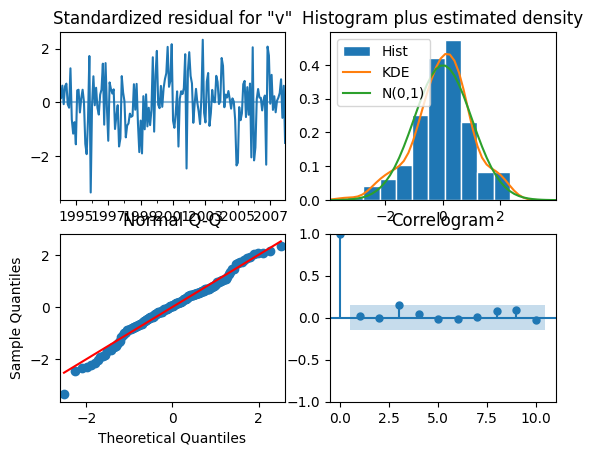

In [ ]:
arima_final_model1_fit.plot_diagnostics();

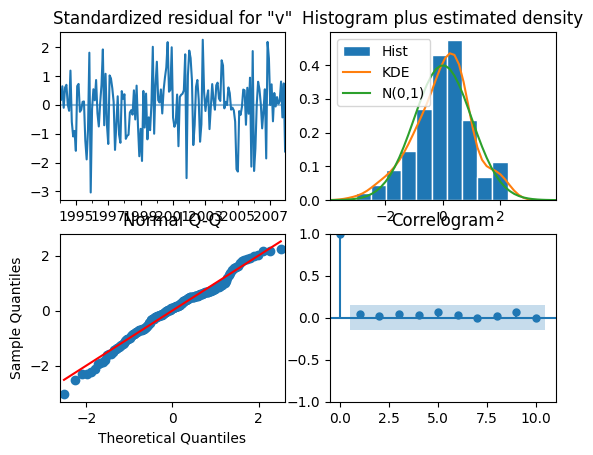

In [ ]:
arima_final_model2_fit.plot_diagnostics();

###Escolha do melhor modelo ARIMA

- Os códigos abaixo apresentam as análises dos diferentes modelos ARIMA gerados a fim de escolher aquele que representou melhor os resultados

- De início, utiliza-se o modelo ARIMA, com os dois parâmetros escolhoidos a fim de obter o modelo treinado, utilizando os dados de validação

In [ ]:
arima_final_model_test1 = ARIMA(validation_fluv, order=arim_param_chosen1)
arima_final_model_test1_fit = arima_final_model_test1.fit()

In [ ]:
arima_final_model_test2 = ARIMA(validation_fluv, order=arim_param_chosen2)
arima_final_model_test2_fit = arima_final_model_test2.fit()

In [ ]:
#Estabelecendo as dimensões máximas e mínimas, onde começa e termina cada conjunto
start_train = len(train_fluv)
end_train = len(train_fluv) + len(validation_fluv) - 1

start_val = len(validation_fluv) + len(train_fluv)
end_val = len(train_fluv) + len(validation_fluv) + len(test_fluv) - 1

In [ ]:
def add_prediction_to_df(prediction,df,index_value,column_name):
  prediction_series = pd.Series(prediction)
  prediction_df = pd.DataFrame({column_name: prediction_series.values}, index=index_value.index)
  df[column_name] = prediction_df
  return df

- De posse dos modelos treinados, é feita a predição para os dados, tanto de validação quanto de teste

In [ ]:
previsao1 = arima_final_model1_fit.predict(start=start_train, end=end_train,typ='levels')
previsao2 = arima_final_model2_fit.predict(start=start_train, end=end_train,typ='levels')

In [ ]:
previsao1_test = arima_final_model_test1_fit.predict(start=start_val, end=end_val,typ='levels')
previsao2_test = arima_final_model_test2_fit.predict(start=start_val, end=end_val,typ='levels')

In [ ]:
df_pluv_st_filt = add_prediction_to_df(previsao1,df_pluv_st_filt,validation_fluv,'previsao1')
df_pluv_st_filt = add_prediction_to_df(previsao2,df_pluv_st_filt,validation_fluv,'previsao2')
df_pluv_st_filt = add_prediction_to_df(previsao1_test,df_pluv_st_filt,test_fluv,'previsao1_test')
df_pluv_st_filt = add_prediction_to_df(previsao2_test,df_pluv_st_filt,test_fluv,'previsao2_test')

- Depois de realizadas as predições dos dados, é necessário fazer a conversão para que eles voltem ao padão dos dados iniciais
- Este processo segue algumas fases:
  - desnormalização dos dados
  - conversão dos valores normalizados, considerando a logarização e desazonalização feita


In [ ]:
def convert_prev_value(value_prev,saz1=None,saz2=None,value_log=None):
  if value_log is not None:
    value_convert = np.exp(value_prev*saz1*saz2)
  return value_convert

In [ ]:
df_pluv_st_filt['previsao1_desn'] = desnormalizar_colunas(df_pluv_st_filt['previsao1'],max_value,min_value)
df_pluv_st_filt['previsao2_desn'] = desnormalizar_colunas(df_pluv_st_filt['previsao2'],max_value,min_value)

df_pluv_st_filt['previsao1_desn_test'] = desnormalizar_colunas(df_pluv_st_filt['previsao1_test'],max_value,min_value)
df_pluv_st_filt['previsao2_desn_test'] = desnormalizar_colunas(df_pluv_st_filt['previsao2_test'],max_value,min_value)

In [ ]:
df_pluv_st_filt['pred1_final'] = convert_prev_value(df_pluv_st_filt['previsao1_desn'],df_pluv_st_filt['sazonalidade'],df_pluv_st_filt['sazonalidade2'],value_log='log')
df_pluv_st_filt['pred2_final'] = convert_prev_value(df_pluv_st_filt['previsao2_desn'],df_pluv_st_filt['sazonalidade'],df_pluv_st_filt['sazonalidade2'],value_log='log')

df_pluv_st_filt['pred1_final_test'] = convert_prev_value(df_pluv_st_filt['previsao1_desn_test'],df_pluv_st_filt['sazonalidade'],df_pluv_st_filt['sazonalidade2'],value_log='log')
df_pluv_st_filt['pred2_final_test'] = convert_prev_value(df_pluv_st_filt['previsao2_desn_test'],df_pluv_st_filt['sazonalidade'],df_pluv_st_filt['sazonalidade2'],value_log='log')

In [ ]:
df_pluv_st_filt[end_train-1:]

,value,final_date,log_value,sazonalidade,value_desaz,sazonalidade2,value_desaz2,value_norm,previsao1,previsao2,previsao1_test,previsao2_test,previsao1_desn,previsao2_desn,previsao1_desn_test,previsao2_desn_test,pred1_final,pred2_final,pred1_final_test,pred2_final_test
date,,,,,,,,,,,,,,,,,,,,
2014-11-01,56.0,2014-11-01,4.025352,-1.413082,-2.848632,-2.301272,1.237851,0.824146,0.58441,0.584204,NaN,NaN,0.997115,0.996908,NaN,NaN,25.597743,25.580537,NaN,NaN
2014-12-01,71.3,2014-12-01,4.266896,-0.908470,-4.696792,-4.152155,1.131170,0.717908,0.58441,0.584204,NaN,NaN,0.997115,0.996908,NaN,NaN,43.001107,42.967592,NaN,NaN
2015-01-01,64.6,2015-01-01,4.168214,-0.381053,-10.938682,-11.330534,0.965416,0.552843,NaN,NaN,0.629455,0.630109,NaN,NaN,1.042348,1.043004,NaN,NaN,90.050293,90.305967
2015-02-01,54.0,2015-02-01,3.988984,-0.213713,-18.665112,-21.025280,0.887746,0.475496,NaN,NaN,0.629455,0.630109,NaN,NaN,1.042348,1.043004,NaN,NaN,108.166105,108.485742
2015-03-01,341.8,2015-03-01,5.834226,0.419015,13.923659,12.283331,1.133541,0.720269,NaN,NaN,0.629455,0.630109,NaN,NaN,1.042348,1.043004,NaN,NaN,213.761889,214.485594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-01,309.0,2021-08-01,5.733341,0.368541,15.556875,13.835616,1.124408,0.711174,NaN,NaN,0.629455,0.630109,NaN,NaN,1.042348,1.043004,NaN,NaN,203.347777,204.029805
2021-09-01,50.8,2021-09-01,3.927896,-0.482315,-8.143837,-8.740265,0.931761,0.519328,NaN,NaN,0.629455,0.630109,NaN,NaN,1.042348,1.043004,NaN,NaN,80.970280,81.194737
2021-10-01,42.8,2021-10-01,3.756538,-1.146695,-3.275968,-3.074744,1.065444,0.652455,NaN,NaN,0.629455,0.630109,NaN,NaN,1.042348,1.043004,NaN,NaN,39.452787,39.544239


####Análise dos resultados - modelo ARIMA

In [ ]:
def print_media_previsoes(start,end,titulo,real_value,previsao1,previsao2=None):
  print(titulo)
  print('A média das previsões é (Prev 01):',previsao1.iloc[start:end+1].mean())
  if previsao2 is not None:
   print('A média das previsões é (Prev 02):',previsao2.iloc[start:end+1].mean())
  print('A média dos valores reais é: ',real_value.iloc[start:end+1].mean(),'\n')


In [ ]:
def extract_errors(start,end,real_value,prediction,model_title):
  rmse_value = rmse(prediction.iloc[start:end+1],real_value.iloc[start:end+1])
  mae_value = mean_absolute_error(prediction.iloc[start:end+1],real_value.iloc[start:end+1])
  r2_value = r2_score(prediction.iloc[start:end+1],real_value.iloc[start:end+1])

  print(f'O RMSE do {model_title} é:',rmse_value)
  print(f'O MAE do {model_title} é:',mae_value)
  print(f'O R² score do {model_title} é:',r2_value,'\n')
  return rmse_value,mae_value, r2_value

- O código abaixo traz uma análise das médias dos valores reais X a média dos valores previstos, tanto para o conjunto de teste, quanto para o conjunto de validação

In [ ]:
print_media_previsoes(start_train,end_train,'Conjunto de Validação',df_pluv_st_filt['value'],df_pluv_st_filt['pred1_final'],previsao2=df_pluv_st_filt['pred2_final'])
print_media_previsoes(start_val,end_val,'Conjunto de Teste',df_pluv_st_filt['value'],df_pluv_st_filt['pred1_final_test'],previsao2=df_pluv_st_filt['pred2_final_test'])

Conjunto de Validação
A média das previsões é (Prev 01): 152.09629651304513
A média das previsões é (Prev 02): 152.45031362123834
A média dos valores reais é:  198.175 

Conjunto de Teste
A média das previsões é (Prev 01): 193.49292555214507
A média das previsões é (Prev 02): 194.17039765217692
A média dos valores reais é:  157.30714285714285 



In [ ]:
print('Conjunto de Validação: ')
rmse_prev1_val, mae_prev1_val, r2_prev1_val = extract_errors(start_train,end_train,df_pluv_st_filt['value'],df_pluv_st_filt['pred1_final'],f'modelo ARIMA {arim_param_chosen1}')
rmse_prev2_val, mae_prev2_val, r2_prev2_val = extract_errors(start_train,end_train,df_pluv_st_filt['value'],df_pluv_st_filt['pred2_final'],f'modelo ARIMA {arim_param_chosen2}')

Conjunto de Validação: 
O RMSE do modelo ARIMA (0, 0, 2) é: 113.25427721056182
O MAE do modelo ARIMA (0, 0, 2) é: 75.7333403008851
O R² score do modelo ARIMA (0, 0, 2) é: -0.08642424982654284 

O RMSE do modelo ARIMA (2, 0, 2) é: 113.89103296423127
O MAE do modelo ARIMA (2, 0, 2) é: 75.7968687134732
O R² score do modelo ARIMA (2, 0, 2) é: -0.06030115550174919 



In [ ]:
print('Conjunto de Teste: ')
rmse_prev1_test, mae_prev1_test, r2_prev1_test = extract_errors(start_val,end_val,df_pluv_st_filt['value'],df_pluv_st_filt['pred1_final_test'],f'modelo ARIMA {arim_param_chosen1}')
rmse_prev2_test, mae_prev2_test, r2_prev2_test = extract_errors(start_val,end_val,df_pluv_st_filt['value'],df_pluv_st_filt['pred2_final_test'],f'modelo ARIMA {arim_param_chosen2}')

Conjunto de Teste: 
O RMSE do modelo ARIMA (0, 0, 2) é: 103.69903941037433
O MAE do modelo ARIMA (0, 0, 2) é: 71.89204782650064
O R² score do modelo ARIMA (0, 0, 2) é: 0.47245302584199544 

O RMSE do modelo ARIMA (2, 0, 2) é: 104.12459089701247
O MAE do modelo ARIMA (2, 0, 2) é: 72.08453350155963
O R² score do modelo ARIMA (2, 0, 2) é: 0.4723098235790085 



- O modelo ARIMA (0,0,2) apresentou melhores valores com relação aos erros. Sendo assim, vamos escolher ele como modelo final para este modelo.

In [ ]:
df_pluv_st_filt = df_pluv_st_filt.drop(columns=['previsao1','previsao1_test','previsao2','previsao2_test','pred1_final','pred1_final_test'])

In [ ]:
df_pluv_st_filt = df_pluv_st_filt.rename(columns={'pred2_final': 'pred_arima_val','pred2_final_test': 'pred_arima_test'})

In [ ]:
df_pluv_st_filt = df_pluv_st_filt.drop(columns=['previsao1_desn','previsao2_desn','previsao1_desn_test','previsao2_desn_test'])

In [ ]:
df_pluv_st_filt[190:200]

,value,final_date,log_value,sazonalidade,value_desaz,sazonalidade2,value_desaz2,value_norm,pred_arima_val,pred_arima_test
date,,,,,,,,,,
2009-11-01,49.2,2009-11-01,3.895894,-1.413082,-2.757018,-2.301272,1.198041,0.784501,25.711153,NaN
2009-12-01,48.2,2009-12-01,3.875359,-0.908470,-4.265807,-4.152155,1.027372,0.614542,43.020654,NaN
2010-01-01,193.4,2010-01-01,5.264761,-0.381053,-13.816357,-11.330534,1.219392,0.805763,73.730170,NaN
2010-02-01,44.6,2010-02-01,3.797734,-0.213713,-17.770220,-21.025280,0.845184,0.433111,87.838350,NaN
2010-03-01,89.9,2010-03-01,4.498698,0.419015,10.736358,12.283331,0.874059,0.461866,169.147066,NaN
2010-04-01,273.3,2010-04-01,5.610570,0.785217,7.145247,7.031936,1.016114,0.603330,246.620188,NaN
2010-05-01,115.1,2010-05-01,4.745801,0.921382,5.150742,6.145208,0.838172,0.426128,283.527419,NaN
2010-06-01,540.3,2010-06-01,6.292125,1.114217,5.647127,5.254959,1.074628,0.661601,342.633393,NaN
2010-07-01,265.2,2010-07-01,5.580484,0.936957,5.955963,6.073200,0.980696,0.568060,290.174983,NaN


In [ ]:
error_previsao = pd.DataFrame(columns=['modelo','rmse_train','rmse_val','rmse_test','mae_train','mae_val','mae_test','r2_train','r2_val','r2_test'])

In [ ]:
error_previsao.loc[len(error_previsao)] = ['ARIMA (3,0,2)','-',rmse_prev2_val,rmse_prev2_test,'-',mae_prev2_val,mae_prev2_test,'-',r2_prev2_val,r2_prev2_test]

In [ ]:
error_previsao

,modelo,rmse_train,rmse_val,rmse_test,mae_train,mae_val,mae_test,r2_train,r2_val,r2_test
0,"ARIMA (3,0,2)",-,113.891033,104.124591,-,75.796869,72.084534,-,-0.060301,0.47231


##Modelo MLP e LSTM

Os modelos 02 e 03 são modelos de Aprendizagem de Máquina que seguirão alguns padrões semelhantes
- Modelos escolhidos:
  - MLP
  - LSTM

- Relembrando os conjuntos de treino e teste:
  - train_initial_fluv: Conjunto de Treinamento
    - 0.50 conjunto de treinamento (train_fluv)
    - 0.25 conjunto de validação (validation_fluv)
  - test_fluv: 0.25 Conjunto de teste


In [ ]:
tf.random.set_seed(42)

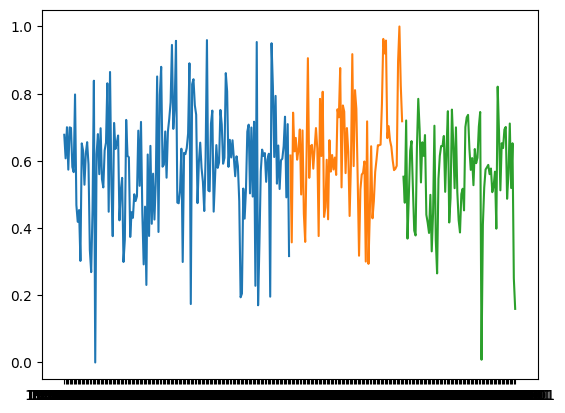

In [ ]:
plt.plot(train_fluv); plt.plot(validation_fluv); plt.plot(test_fluv)

###Janela Deslizante

- Para gerar as variáveis que vão ser modeladas, será utilizada a janela deslizante.
  - Vamos usar uma quantidade X de informações anteriores para prever a próxima

In [ ]:
df_pluv_am = copy.deepcopy(df_pluv_st_filt)

In [ ]:
df_pluv_am

,value,final_date,log_value,sazonalidade,value_desaz,sazonalidade2,value_desaz2,value_norm,pred_arima_val,pred_arima_test
date,,,,,,,,,,
1994-01-01,111.0,1994-01-01,4.709530,-0.381053,-12.359261,-11.330534,1.090792,0.677698,NaN,NaN
1994-02-01,98.0,1994-02-01,4.584967,-0.213713,-21.453816,-21.025280,1.020382,0.607581,NaN,NaN
1994-03-01,308.1,1994-03-01,5.730424,0.419015,13.675932,12.283331,1.113373,0.700185,NaN,NaN
1994-04-01,232.2,1994-04-01,5.447599,0.785217,6.937698,7.031936,0.986599,0.573938,NaN,NaN
1994-05-01,545.4,1994-05-01,6.301519,0.921382,6.839204,6.145208,1.112933,0.699747,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2021-08-01,309.0,2021-08-01,5.733341,0.368541,15.556875,13.835616,1.124408,0.711174,NaN,204.029805
2021-09-01,50.8,2021-09-01,3.927896,-0.482315,-8.143837,-8.740265,0.931761,0.519328,NaN,81.194737
2021-10-01,42.8,2021-10-01,3.756538,-1.146695,-3.275968,-3.074744,1.065444,0.652455,NaN,39.544239


In [ ]:
def get_sliding_windows2(windows_size, df,colum_name):
    # serie: vetor do tipo numpy ou lista
    tam_serie = len(df)
    windows_size = windows_size +1 # Adicionado mais um ponto para retornar o target na janela

    janela = list(df[colum_name][0:0+windows_size]) #primeira janela p criar o objeto np
    janelas_np = np.array(np.transpose(janela))

    for i in range(1, tam_serie-windows_size+1):  #começa do 1
        janela = list(df[colum_name][i:i+windows_size])
        j_np = np.array(np.transpose(janela))

        janelas_np = np.vstack((janelas_np, j_np))
        columns_ = []

    for i in range(1, windows_size): columns_.append('t_' + str(windows_size-i))
    columns_.append('target')

    new_df = pd.DataFrame(janelas_np, columns=columns_)
    new_df.index = df.index[windows_size-1:]

    result_df = pd.concat([df,new_df],axis=1)

    return result_df

- De início, será testado um LAG de 15, para ver como os dados se comportam e a correlação entre eles
  - Neste caso, vão ser utilizados os 15 últimos valores para prever o 16º

In [ ]:
lag_size = 15

In [ ]:
df_pluv_am = get_sliding_windows2(lag_size, df_pluv_am,'value_norm')

In [ ]:
df_pluv_am[13:]

,value,final_date,log_value,sazonalidade,value_desaz,sazonalidade2,value_desaz2,value_norm,pred_arima_val,pred_arima_test,...,t_9,t_8,t_7,t_6,t_5,t_4,t_3,t_2,t_1,target
date,,,,,,,,,,,,,,,,,,,,,
1995-02-01,119.8,1995-02-01,4.785824,-0.213713,-22.393655,-21.025280,1.065082,0.652095,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-03-01,214.3,1995-03-01,5.367377,0.419015,12.809502,12.283331,1.042836,0.629941,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-04-01,181.0,1995-04-01,5.198497,0.785217,6.620459,7.031936,0.941484,0.529011,NaN,NaN,...,0.581946,0.566481,0.797618,0.468315,0.418693,0.453606,0.302286,0.652095,0.629941,0.529011
1995-05-01,350.5,1995-05-01,5.859361,0.921382,6.359317,6.145208,1.034842,0.621980,NaN,NaN,...,0.566481,0.797618,0.468315,0.418693,0.453606,0.302286,0.652095,0.629941,0.529011,0.621980
1995-06-01,521.8,1995-06-01,6.257284,1.114217,5.615858,5.254959,1.068678,0.655676,NaN,NaN,...,0.797618,0.468315,0.418693,0.453606,0.302286,0.652095,0.629941,0.529011,0.621980,0.655676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-01,309.0,2021-08-01,5.733341,0.368541,15.556875,13.835616,1.124408,0.711174,NaN,204.029805,...,0.820847,0.684815,0.512356,0.652465,0.637988,0.693429,0.701032,0.487219,0.561744,0.711174
2021-09-01,50.8,2021-09-01,3.927896,-0.482315,-8.143837,-8.740265,0.931761,0.519328,NaN,81.194737,...,0.684815,0.512356,0.652465,0.637988,0.693429,0.701032,0.487219,0.561744,0.711174,0.519328
2021-10-01,42.8,2021-10-01,3.756538,-1.146695,-3.275968,-3.074744,1.065444,0.652455,NaN,39.544239,...,0.512356,0.652465,0.637988,0.693429,0.701032,0.487219,0.561744,0.711174,0.519328,0.652455


In [ ]:
correlation_matrix = copy.deepcopy(df_pluv_am)

In [ ]:
correlation_matrix = correlation_matrix.drop(columns=['final_date'])

In [ ]:
correlation_matrix = correlation_matrix.corr()

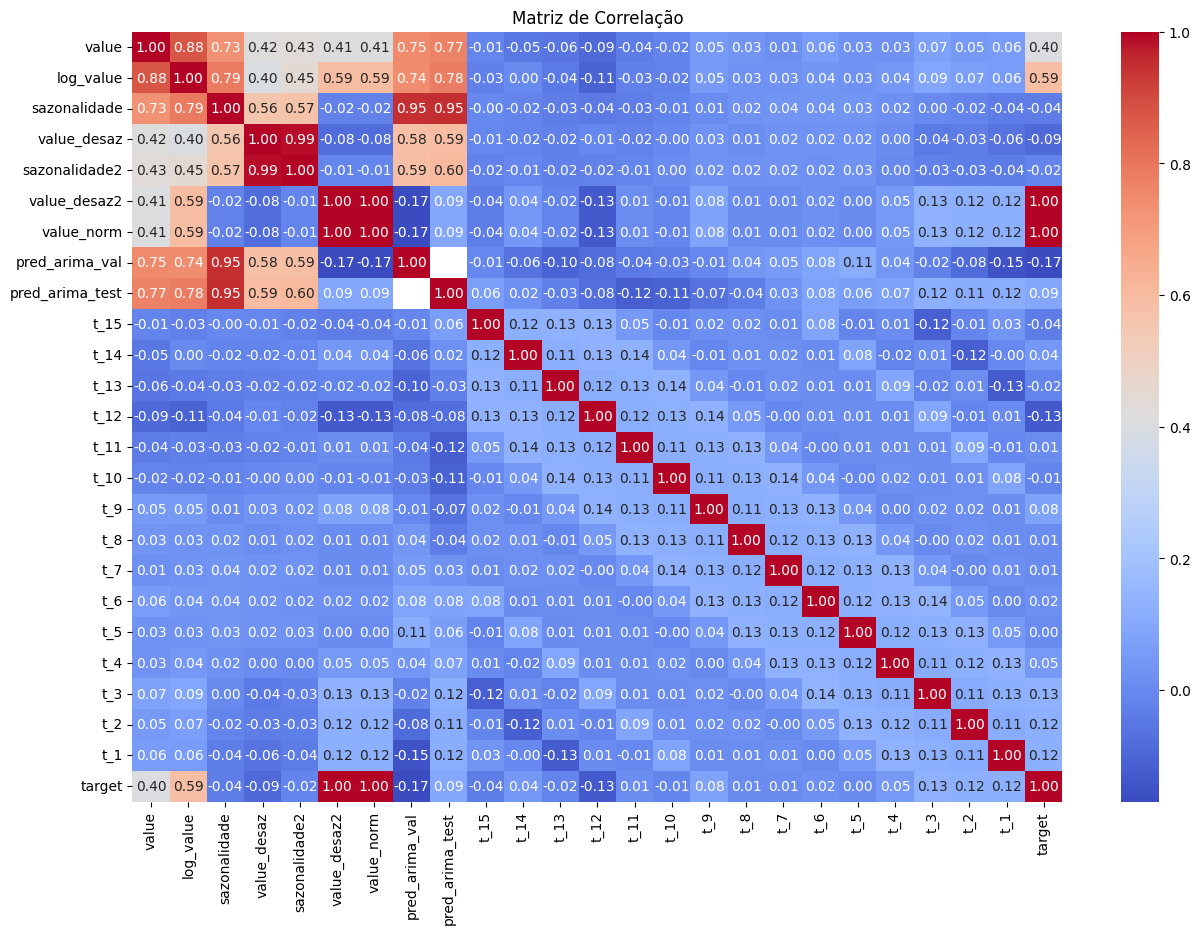

In [ ]:
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Matriz de Correlação")
plt.show()

In [ ]:
columns_lag = [f't_{i}' for i in range(1,lag_size+1)]
columns_lag.append('target')
columns_lag

['t_1',
 't_2',
 't_3',
 't_4',
 't_5',
 't_6',
 't_7',
 't_8',
 't_9',
 't_10',
 't_11',
 't_12',
 't_13',
 't_14',
 't_15',
 'target']

In [ ]:
df_pluv_am = df_pluv_am.drop(columns=columns_lag)

In [ ]:
df_pluv_am2 = copy.deepcopy(df_pluv_st_filt)

- De posse dessa matriz de correlação, foi escolhido alterar o valor do lag, que antes era 15 para 3. A partir do 4 valor a correlação com o valor real, target, diminui bastante

In [ ]:
lag_size2 = 3

In [ ]:
df_pluv_am2 = get_sliding_windows2(lag_size2, df_pluv_am2,'value_norm')

In [ ]:
df_pluv_am2

,value,final_date,log_value,sazonalidade,value_desaz,sazonalidade2,value_desaz2,value_norm,pred_arima_val,pred_arima_test,t_3,t_2,t_1,target
date,,,,,,,,,,,,,,
1994-01-01,111.0,1994-01-01,4.709530,-0.381053,-12.359261,-11.330534,1.090792,0.677698,NaN,NaN,NaN,NaN,NaN,NaN
1994-02-01,98.0,1994-02-01,4.584967,-0.213713,-21.453816,-21.025280,1.020382,0.607581,NaN,NaN,NaN,NaN,NaN,NaN
1994-03-01,308.1,1994-03-01,5.730424,0.419015,13.675932,12.283331,1.113373,0.700185,NaN,NaN,NaN,NaN,NaN,NaN
1994-04-01,232.2,1994-04-01,5.447599,0.785217,6.937698,7.031936,0.986599,0.573938,NaN,NaN,0.677698,0.607581,0.700185,0.573938
1994-05-01,545.4,1994-05-01,6.301519,0.921382,6.839204,6.145208,1.112933,0.699747,NaN,NaN,0.607581,0.700185,0.573938,0.699747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-01,309.0,2021-08-01,5.733341,0.368541,15.556875,13.835616,1.124408,0.711174,NaN,204.029805,0.701032,0.487219,0.561744,0.711174
2021-09-01,50.8,2021-09-01,3.927896,-0.482315,-8.143837,-8.740265,0.931761,0.519328,NaN,81.194737,0.487219,0.561744,0.711174,0.519328
2021-10-01,42.8,2021-10-01,3.756538,-1.146695,-3.275968,-3.074744,1.065444,0.652455,NaN,39.544239,0.561744,0.711174,0.519328,0.652455


In [ ]:
df_pluv_am_train = df_pluv_am2[lag_size2:]

In [ ]:
df_pluv_am_train = df_pluv_am_train.drop(columns=['log_value','sazonalidade','value_desaz','sazonalidade2','value_desaz2','pred_arima_val','pred_arima_test'])

In [ ]:
df_pluv_am_train

,value,final_date,value_norm,t_3,t_2,t_1,target
date,,,,,,,
1994-04-01,232.2,1994-04-01,0.573938,0.677698,0.607581,0.700185,0.573938
1994-05-01,545.4,1994-05-01,0.699747,0.607581,0.700185,0.573938,0.699747
1994-06-01,669.7,1994-06-01,0.698118,0.700185,0.573938,0.699747,0.698118
1994-07-01,287.1,1994-07-01,0.581946,0.573938,0.699747,0.698118,0.581946
1994-08-01,147.3,1994-08-01,0.566481,0.699747,0.698118,0.581946,0.566481
...,...,...,...,...,...,...,...
2021-08-01,309.0,2021-08-01,0.711174,0.701032,0.487219,0.561744,0.711174
2021-09-01,50.8,2021-09-01,0.519328,0.487219,0.561744,0.711174,0.519328
2021-10-01,42.8,2021-10-01,0.652455,0.561744,0.711174,0.519328,0.652455


###Separação dos dados em treinamento, validação e teste

- Dessa vez, o conjunto de treinamento, validação e teste vai levar em consideração os seguintes valores:
  - X valor: t_1, t_2 e t_3
  - y valor: target --> valor real almejado

In [ ]:
train_initial_fluv_am, test_fluv_am = train_test_split(df_pluv_am_train, test_size=test_split, shuffle=False)
train_fluv_am, validation_fluv_am = train_test_split(train_initial_fluv_am, test_size=val_split_final, shuffle=False)

In [ ]:
X_train_fluv = train_fluv_am.drop(columns=['target','value','final_date','value_norm'])
X_validation_fluv = validation_fluv_am.drop(columns=['target','value','final_date','value_norm'])
X_test_fluv = test_fluv_am.drop(columns=['target','value','final_date','value_norm'])

y_train_fluv = train_fluv_am.target
y_validation_fluv = validation_fluv_am.target
y_test_fluv = test_fluv_am.target

In [ ]:
#Estabelecendo as dimensões máximas e mínimas, onde começa e termina cada conjunto
start_am_train = len(X_train_fluv)
end__am_train = len(X_train_fluv) + len(X_validation_fluv) - 1

start_am_val = len(X_train_fluv) + len(X_validation_fluv)
end_am_val = len(X_train_fluv) + len(X_validation_fluv) + len(X_test_fluv) - 1

In [ ]:
#dimensões finais, acrescidas do lag escolhido
start_am_train_f = len(X_train_fluv) + lag_size
end__am_train_f = len(X_train_fluv) + len(X_validation_fluv) - 1 + lag_size

start_am_val_f = len(X_train_fluv) + len(X_validation_fluv) + lag_size
end_am_val_f = len(X_train_fluv) + len(X_validation_fluv) + len(X_test_fluv) - 1 + lag_size

- O gráfico abaixo apresenta a segregação dos dados de treinamento, validação e teste

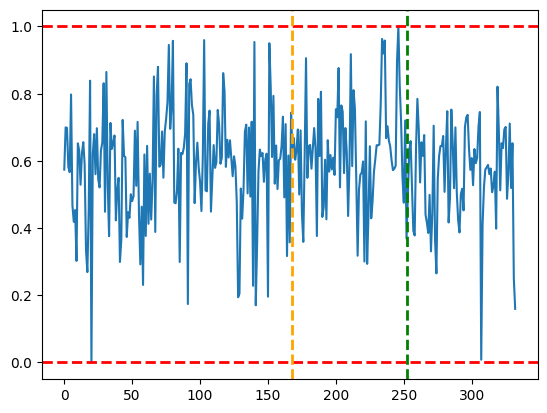

In [ ]:
plt.plot(np.concatenate([train_fluv_am['value_norm'], validation_fluv_am['value_norm'],test_fluv_am['value_norm']]))
plt.axhline(y=1.0, c="r", linewidth=2, linestyle = '--')
plt.axhline(y=0.0, c="r", linewidth=2, linestyle = '--')
plt.axvline(x=len(train_fluv), c="orange", linewidth=2, linestyle = '--')
plt.axvline(x=(len(train_fluv)+len(validation_fluv)), c="green", linewidth=2, linestyle = '--')

 ### Modelo MLP (Modelo 02)

- O segundo modelo aplicado é o MLP (Perceptron Multicamadas)
- Ele se assemelha ao perceptron simples, entretanto possui mais de uma camada de neurônios com uma ou mais camadas ocultas
- Para este modelo será utilizado o `MLPRegressor`


In [ ]:
mlp_model = MLPRegressor(max_iter=5000)


- O param_list_mlp vai trazer diferentes parâmetros a serem aplicados no modelo, a fim de encontrar aqueles que trazem um melhor resultado
  - Para isso, será utilizado o `RandomizedSearchCV`

####Escolha dos Parâmetros do modelo

In [ ]:
param_list_mlp = {"hidden_layer_sizes": [(1,),(50,)],
                  "activation": ["identity", "logistic", "tanh", "relu"],
                  "solver": ["lbfgs", "sgd", "adam"],
                  "alpha": [0.000005,0.00005,0.0005]}

In [ ]:
grid_search_mlp = RandomizedSearchCV(
    mlp_model,
    param_list_mlp,
    n_iter=20,
    cv=3,
    verbose=2)

In [ ]:
grid_search_mlp.fit(X_train_fluv, y_train_fluv)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END activation=identity, alpha=5e-06, hidden_layer_sizes=(50,), solver=sgd; total time=   0.0s
[CV] END activation=identity, alpha=5e-06, hidden_layer_sizes=(50,), solver=sgd; total time=   0.0s
[CV] END activation=identity, alpha=5e-06, hidden_layer_sizes=(50,), solver=sgd; total time=   0.0s
[CV] END activation=relu, alpha=5e-05, hidden_layer_sizes=(1,), solver=adam; total time=   0.4s
[CV] END activation=relu, alpha=5e-05, hidden_layer_sizes=(1,), solver=adam; total time=   0.8s
[CV] END activation=relu, alpha=5e-05, hidden_layer_sizes=(1,), solver=adam; total time=   0.0s
[CV] END activation=logistic, alpha=5e-06, hidden_layer_sizes=(1,), solver=lbfgs; total time=   0.0s
[CV] END activation=logistic, alpha=5e-06, hidden_layer_sizes=(1,), solver=lbfgs; total time=   0.0s
[CV] END activation=logistic, alpha=5e-06, hidden_layer_sizes=(1,), solver=lbfgs; total time=   0.0s
[CV] END activation=identity, alpha=5e-06, hidde

RandomizedSearchCV(cv=3, estimator=MLPRegressor(max_iter=5000), n_iter=20,
                   param_distributions={'activation': ['identity', 'logistic',
                                                       'tanh', 'relu'],
                                        'alpha': [5e-06, 5e-05, 0.0005],
                                        'hidden_layer_sizes': [(1,), (50,)],
                                        'solver': ['lbfgs', 'sgd', 'adam']},
                   verbose=2)

In [ ]:
print("Melhores parâmetros encontrados:", grid_search_mlp.best_params_)
best_params_mlp = grid_search_mlp.best_params_

Melhores parâmetros encontrados: {'solver': 'lbfgs', 'hidden_layer_sizes': (1,), 'alpha': 5e-06, 'activation': 'identity'}


####Análise dos dados de acordo com o melhor modelo escolhido

- De posse dos melhores parâmetros encontrados defini-se o melhor modelo para MLP
- Através do melhor modelo, pode-se encontrar o valor previsto para o conjunto de validação e gerar um novo modelo, com os melhores parâmetros, para obter os valores previstos de teste

In [ ]:
# Avaliar o modelo no conjunto de validação
best_model_mlp = grid_search_mlp.best_estimator_

In [ ]:
val_predictions = best_model_mlp.predict(X_validation_fluv)
val_mse = mean_squared_error(y_validation_fluv, val_predictions)
print(f"Mean Squared Error no conjunto de validação: {val_mse:.4f}")

Mean Squared Error no conjunto de validação: 0.0236


In [ ]:
# val_predictions_df = pd.DataFrame(val_predictions, columns=['prev_mlp_val'])
y_validation_fluv_df = y_validation_fluv.to_frame(name='value_mlp_val')

In [ ]:
prediction_series_val = pd.Series(val_predictions)
val_predictions_df = pd.DataFrame({'prev_mlp_val': prediction_series_val.values}, index=y_validation_fluv_df.index)

In [ ]:
y_validation_fluv_df['prev_mlp_val'] = val_predictions_df

In [ ]:
best_mlp_model = MLPRegressor(**best_params_mlp)

In [ ]:
best_mlp_model.fit(X_validation_fluv, y_validation_fluv)

MLPRegressor(activation='identity', alpha=5e-06, hidden_layer_sizes=(1,),
             solver='lbfgs')

In [ ]:
# Avaliar no conjunto de teste
test_predictions = best_mlp_model.predict(X_test_fluv)
test_mse = mean_squared_error(y_test_fluv, test_predictions)
print(f"Mean Squared Error no conjunto de teste: {test_mse:.4f}")

Mean Squared Error no conjunto de teste: 0.0240


In [ ]:
y_test_fluv_df = y_test_fluv.to_frame(name='value_mlp_test')

In [ ]:
prediction_series_test = pd.Series(test_predictions)
test_predictions_df = pd.DataFrame({'prev_mlp_test': prediction_series_test.values}, index=y_test_fluv_df.index)
y_test_fluv_df['prev_mlp_test'] = test_predictions_df

- Depois de realizadas as predições dos dados, é necessário fazer a conversão para que eles voltem ao padão dos dados iniciais
- Este processo segue algumas fases:
  - desnormalização dos dados
  - conversão dos valores normalizados, considerando a logarização e desazonalização feita

In [ ]:
y_validation_fluv_df['prev_mlp_val_desn'] = desnormalizar_colunas(y_validation_fluv_df['prev_mlp_val'],max_value,min_value)
y_test_fluv_df['prev_mlp_test_desn'] = desnormalizar_colunas(y_test_fluv_df['prev_mlp_test'],max_value,min_value)

In [ ]:
result_val_mlp = y_validation_fluv_df.join(df_pluv_st_filt, how="left")
result_val_mlp

,value_mlp_val,prev_mlp_val,prev_mlp_val_desn,value,final_date,log_value,sazonalidade,value_desaz,sazonalidade2,value_desaz2,value_norm,pred_arima_val,pred_arima_test
date,,,,,,,,,,,,,
2008-02-01,0.357444,0.570289,0.982935,31.7,2008-02-01,3.456317,-0.213713,-16.172673,-21.025280,0.769201,0.357444,79.254034,NaN
2008-03-01,0.743548,0.549562,0.962121,385.5,2008-03-01,5.954541,0.419015,14.210798,12.283331,1.156917,0.743548,133.195360,NaN
2008-04-01,0.628367,0.559404,0.972004,314.0,2008-04-01,5.749393,0.785217,7.322043,7.031936,1.041256,0.628367,222.700171,NaN
2008-05-01,0.668452,0.566948,0.979580,456.5,2008-05-01,6.123589,0.921382,6.646091,6.145208,1.081508,0.668452,316.260478,NaN
2008-06-01,0.603522,0.610759,1.023574,384.0,2008-06-01,5.950643,1.114217,5.340650,5.254959,1.016307,0.603522,402.889895,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-08-01,0.585420,0.584304,0.997008,162.3,2014-08-01,5.089446,0.368541,13.809728,13.835616,0.998129,0.585420,161.292934,NaN
2014-09-01,0.895776,0.580285,0.992972,250.0,2014-09-01,5.521461,-0.482315,-11.447827,-8.740265,1.309780,0.895776,66.855166,NaN
2014-10-01,1.000000,0.577958,0.990635,146.5,2014-10-01,4.987025,-1.146695,-4.349041,-3.074744,1.414440,1.000000,33.612355,NaN


In [ ]:
result_test_mlp = y_test_fluv_df.join(df_pluv_st_filt, how="left")
result_test_mlp

,value_mlp_test,prev_mlp_test,prev_mlp_test_desn,value,final_date,log_value,sazonalidade,value_desaz,sazonalidade2,value_desaz2,value_norm,pred_arima_val,pred_arima_test
date,,,,,,,,,,,,,
2015-01-01,0.552843,0.701396,1.114589,64.6,2015-01-01,4.168214,-0.381053,-10.938682,-11.330534,0.965416,0.552843,NaN,90.305967
2015-02-01,0.475496,0.644048,1.057001,54.0,2015-02-01,3.988984,-0.213713,-18.665112,-21.025280,0.887746,0.475496,NaN,108.485742
2015-03-01,0.720269,0.592700,1.005439,341.8,2015-03-01,5.834226,0.419015,13.923659,12.283331,1.133541,0.720269,NaN,214.485594
2015-04-01,0.368669,0.613401,1.026227,74.4,2015-04-01,4.309456,0.785217,5.488235,7.031936,0.780473,0.368669,NaN,317.046609
2015-05-01,0.495752,0.598921,1.011687,171.0,2015-05-01,5.141664,0.921382,5.580382,6.145208,0.908087,0.495752,NaN,367.079478
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-01,0.711174,0.593736,1.006479,309.0,2021-08-01,5.733341,0.368541,15.556875,13.835616,1.124408,0.711174,NaN,204.029805
2021-09-01,0.519328,0.626919,1.039801,50.8,2021-09-01,3.927896,-0.482315,-8.143837,-8.740265,0.931761,0.519328,NaN,81.194737
2021-10-01,0.652455,0.626740,1.039621,42.8,2021-10-01,3.756538,-1.146695,-3.275968,-3.074744,1.065444,0.652455,NaN,39.544239


In [ ]:
result_val_mlp['mlp_final_value_val'] = convert_prev_value(result_val_mlp['prev_mlp_val_desn'],result_val_mlp['sazonalidade'],result_val_mlp['sazonalidade2'],value_log='log')
result_test_mlp['mlp_final_value_test'] = convert_prev_value(result_test_mlp['prev_mlp_test_desn'],result_test_mlp['sazonalidade'],result_test_mlp['sazonalidade2'],value_log='log')


####Análise dos resultados - Modelo MLP

In [ ]:
def print_media_previsoes_dl(titulo,real_value,previsao):
  print(titulo)
  print('A média das previsões é:',previsao.mean())
  print('A média dos valores reais é: ',real_value.mean(),'\n')

In [ ]:
def extract_errors_dl(real_value,prediction,model_title):
  rmse_value = rmse(prediction,real_value)
  mae_value = mean_absolute_error(prediction,real_value)
  r2_value = r2_score(prediction,real_value)

  print(f'O RMSE do {model_title} é:',rmse_value)
  print(f'O MAE do {model_title} é:',mae_value)
  print(f'O R² score do {model_title} é:',r2_value,'\n')
  return rmse_value,mae_value, r2_value

- O código abaixo traz uma análise das médias dos valores reais X a média dos valores previstos, tanto para o conjunto de teste, quanto para o conjunto de validação

In [ ]:
print_media_previsoes_dl('Conjunto de Validação',result_val_mlp['value'],result_val_mlp['mlp_final_value_val'])
print_media_previsoes_dl('Conjunto de Teste',result_test_mlp['value'],result_test_mlp['mlp_final_value_test'])

Conjunto de Validação
A média das previsões é: 159.8613021812417
A média dos valores reais é:  199.53975903614457 

Conjunto de Teste
A média das previsões é: 177.68034691656297
A média dos valores reais é:  157.30714285714285 



In [ ]:

print('Conjunto de Validação:')
rmse_mlp_val, mae_mlp_val, r2_mlp_val = extract_errors_dl(result_val_mlp['value'],result_val_mlp['mlp_final_value_val'],'modelo MLP')

print('Conjunto de Teste: ')
rmse_mlp_test, mae_mlp_test, r2_mlp_test = extract_errors_dl(result_test_mlp['value'],result_test_mlp['mlp_final_value_test'],'modelo MLP')

Conjunto de Validação:
O RMSE do modelo MLP é: 108.52766976291336
O MAE do modelo MLP é: 71.95842742808482
O R² score do modelo MLP é: 0.1235806473586456 

Conjunto de Teste: 
O RMSE do modelo MLP é: 100.38339752970676
O MAE do modelo MLP é: 69.80263238991098
O R² score do modelo MLP é: 0.4550716191599822 



In [ ]:
error_previsao.loc[len(error_previsao)] = ['MLP','-',rmse_mlp_val,rmse_mlp_test,'-',mae_mlp_val,mae_mlp_test,'-',r2_mlp_val,r2_mlp_test]

### Modelo LSTM (Modelo 03)

- O modelo LSTM recebe dados de entrada de tamanho 3D, o que lhe diferencia do MLP
- Abaixo será feita uma apresentação dos dados, do tamanho utilizado no modelo 02, seguida da conversão para 3D;
- Os dados 3D devem ter a seguinte representatividade:
  - (número de amostras, tamanho da janela (lag),1)
  - Para este projeto, o tamanho da janela escolhida foi 3

In [ ]:
print(' - X VALUES:')
print(f'X train data shape: {X_train_fluv.shape}')
print(f'X validation data shape: {X_validation_fluv.shape}')
print(f'X test data shape: {X_test_fluv.shape}')
print('\n - TARGET VALUES:')
print(f'y train data shape: {y_train_fluv.shape}')
print(f'y validation data shape: {y_validation_fluv.shape}')
print(f'y test data shape: {y_test_fluv.shape}')

 - X VALUES:
X train data shape: (166, 3)
X validation data shape: (83, 3)
X test data shape: (84, 3)

 - TARGET VALUES:
y train data shape: (166,)
y validation data shape: (83,)
y test data shape: (84,)


In [ ]:
X_train_lstm = np.expand_dims(X_train_fluv, axis=-1)  # Forma (n_samples, window_size, 1)
X_validation_lstm = np.expand_dims(X_validation_fluv, axis=-1)  # Forma (n_samples, window_size, 1)
X_test_lstm = np.expand_dims(X_test_fluv, axis=-1)  # Forma (n_samples, window_size, 1)

In [ ]:
y_train_lstm = np.array(y_train_fluv).reshape(-1, 1)
y_validation_lstm = np.array(y_validation_fluv).reshape(-1, 1)
y_test_lstm = np.array(y_test_fluv).reshape(-1, 1)

In [ ]:
print(' - X VALUES LSTM:')
print(f'X train data shape: {X_train_lstm.shape}')
print(f'X validation data shape: {X_validation_lstm.shape}')
print(f'X test data shape: {X_test_lstm.shape}')

 - X VALUES LSTM:
X train data shape: (166, 3, 1)
X validation data shape: (83, 3, 1)
X test data shape: (84, 3, 1)


####Escolha dos Parâmetros do modelo

- Para este modelo, o GridSearch foi feito manualmente
- Os parâmetros que variáveis foram escolhidos e concatenados dentro de uma lista de parâmetros
- Essa lista de parâmetros é formada por 5 elementos:
  - Neurônios
  - Função de Ativação
  - Otimizados
  - Bath Size
  - Épocas

In [ ]:
neurons = [50, 100, 200]
activation = ['tanh', 'relu']
optimizer = ['adam', 'sgd']
bath_size = [16, 32]
epochs = [30,50]

params_lstm = list(itertools.product(neurons,activation,optimizer,bath_size,epochs))
print(f'Len params LSTM: {len(params_lstm)}')
print(params_lstm)

Len params LSTM: 48
[(50, 'tanh', 'adam', 16, 30), (50, 'tanh', 'adam', 16, 50), (50, 'tanh', 'adam', 32, 30), (50, 'tanh', 'adam', 32, 50), (50, 'tanh', 'sgd', 16, 30), (50, 'tanh', 'sgd', 16, 50), (50, 'tanh', 'sgd', 32, 30), (50, 'tanh', 'sgd', 32, 50), (50, 'relu', 'adam', 16, 30), (50, 'relu', 'adam', 16, 50), (50, 'relu', 'adam', 32, 30), (50, 'relu', 'adam', 32, 50), (50, 'relu', 'sgd', 16, 30), (50, 'relu', 'sgd', 16, 50), (50, 'relu', 'sgd', 32, 30), (50, 'relu', 'sgd', 32, 50), (100, 'tanh', 'adam', 16, 30), (100, 'tanh', 'adam', 16, 50), (100, 'tanh', 'adam', 32, 30), (100, 'tanh', 'adam', 32, 50), (100, 'tanh', 'sgd', 16, 30), (100, 'tanh', 'sgd', 16, 50), (100, 'tanh', 'sgd', 32, 30), (100, 'tanh', 'sgd', 32, 50), (100, 'relu', 'adam', 16, 30), (100, 'relu', 'adam', 16, 50), (100, 'relu', 'adam', 32, 30), (100, 'relu', 'adam', 32, 50), (100, 'relu', 'sgd', 16, 30), (100, 'relu', 'sgd', 16, 50), (100, 'relu', 'sgd', 32, 30), (100, 'relu', 'sgd', 32, 50), (200, 'tanh', 'adam

- De posse da lista de parâmetros, é feito um FOR no modelo LSTM para que todos eles sejam treinados
  - A cada iteração observa-se o valor da `loss` e então, o modelo que apresentar este menor valor será escolhido como o melhor

In [ ]:
for i,param_lstm in enumerate(params_lstm):
  print(f'Modelo {i}')
  lstm_model = Sequential()
  lstm_model.add(LSTM(params_lstm[i][0], activation=params_lstm[i][1], input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
  lstm_model.add(Dense(1))

  # Fit do modelo
  lstm_model.compile(loss='mean_squared_error', optimizer=params_lstm[i][2], metrics=['mean_squared_error'])
  history = lstm_model.fit(X_train_lstm, y_train_lstm, epochs=params_lstm[i][4], batch_size=params_lstm[i][3])

  actual_loss = history.history['loss'][-1]

  if i == 0:
    best_model_lstm = i
    lower_loss = actual_loss
    model_chosen_lstm = lstm_model
  else:
    if actual_loss < lower_loss:
      lower_loss = actual_loss
      best_model_lstm = i
      model_chosen_lstm = lstm_model



Modelo 0


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.3677 - mean_squared_error: 0.3677
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2077 - mean_squared_error: 0.2077 
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0935 - mean_squared_error: 0.0935 
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0384 - mean_squared_error: 0.0384 
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0342 - mean_squared_error: 0.0342 
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0321 - mean_squared_error: 0.0321 
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0324 - mean_squared_error: 0.0324 
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0328 - mean_squared_error: 0.0328 
Epoch 9/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0323 - mean_squared_error: 0.0323 
Epoch 10/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0321 - mean_squared_error: 0.0321 
Epoch 11/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [ ]:
model_chosen_lstm

<Sequential name=sequential_9, built=True>

- Abaixo pode-se observar os parâmetros escolhidos para o melhor modelo

In [ ]:
print(f'Best Model LSTM ({best_model_lstm}): {params_lstm[best_model_lstm]}')
print('Parâmetros: ')
print(f'Neurons: {params_lstm[best_model_lstm][0]}')
print(f'Activation: {params_lstm[best_model_lstm][1]}')
print(f'Optimizer: {params_lstm[best_model_lstm][2]}')
print(f'Batch_Size: {params_lstm[best_model_lstm][3]}')
print(f'Epoch: {params_lstm[best_model_lstm][4]}')

Best Model LSTM (9): (50, 'relu', 'adam', 16, 50)
Parâmetros: 
Neurons: 50
Activation: relu
Optimizer: adam
Batch_Size: 16
Epoch: 50


####Análise dos dados de acordo com o melhor modelo escolhido

- Através do melhor modelo, pode-se encontrar o valor previsto para o conjunto de validação e gerar um novo modelo, com os melhores parâmetros, para obter os valores previstos de teste

In [ ]:
val_predictions_lstm = model_chosen_lstm.predict(X_validation_lstm)
val_mse_lstm = mean_squared_error(y_validation_lstm, val_predictions_lstm)
print(f"Mean Squared Error no conjunto de validação: {val_mse_lstm:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Mean Squared Error no conjunto de validação: 0.0232


In [ ]:
lstm_modelfinal = Sequential()
lstm_modelfinal.add(LSTM(params_lstm[best_model_lstm][0], activation=params_lstm[best_model_lstm][1], input_shape=(X_validation_lstm.shape[1], X_validation_lstm.shape[2])))
lstm_modelfinal.add(Dense(1))

# Fit do modelo
lstm_modelfinal.compile(loss='mean_squared_error', optimizer=params_lstm[best_model_lstm][2], metrics=['mean_squared_error'])
model_lstm_test = lstm_modelfinal.fit(X_validation_lstm, y_validation_lstm, epochs=params_lstm[best_model_lstm][4], batch_size=params_lstm[best_model_lstm][3])

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4080 - mean_squared_error: 0.4080
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3577 - mean_squared_error: 0.3577  
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3099 - mean_squared_error: 0.3099  
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2638 - mean_squared_error: 0.2638  
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2184 - mean_squared_error: 0.2184  
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1739 - mean_squared_error: 0.1739 
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1312 - mean_squared_error: 0.1312 
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0919 - mean_squared_error: 0.0919  
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0590 - mean_squared_error: 0.0590 
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0363 - mean_squared_error: 0.0363  
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0261 - mean_squa

In [ ]:
# Avaliar no conjunto de teste
test_predictions_lstm = lstm_modelfinal.predict(X_test_lstm)
test_mse_lstm = mean_squared_error(y_test_lstm, test_predictions_lstm)
print(f"Mean Squared Error no conjunto de teste: {test_mse_lstm:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Mean Squared Error no conjunto de teste: 0.0240


In [ ]:
val_predictions_lstm = val_predictions_lstm.reshape(-1)

In [ ]:
y_validation_lstm_df = y_validation_fluv.to_frame(name='value_lstm_val')

prediction_series_val_lstm = pd.Series(val_predictions_lstm)
val_predictions_df_lstm = pd.DataFrame({'prev_lstm_val': prediction_series_val_lstm.values}, index=y_validation_lstm_df.index)

y_validation_lstm_df['prev_lstm_val'] = val_predictions_df_lstm

In [ ]:
test_predictions_lstm = test_predictions_lstm.reshape(-1)

In [ ]:
y_test_lstm_df = y_test_fluv.to_frame(name='value_lstm_test')

prediction_series_test_lstm = pd.Series(test_predictions_lstm)
test_predictions_df_lstm = pd.DataFrame({'prev_lstm_test': prediction_series_test_lstm.values}, index=y_test_lstm_df.index)

y_test_lstm_df['prev_lstm_test'] = test_predictions_df_lstm

- Depois de realizadas as predições dos dados, é necessário fazer a conversão para que eles voltem ao padão dos dados iniciais
- Este processo segue algumas fases:
  - desnormalização dos dados
  - conversão dos valores normalizados, considerando a logarização e desazonalização feita

In [ ]:
y_validation_lstm_df['prev_lstm_val_desn'] = desnormalizar_colunas(y_validation_lstm_df['prev_lstm_val'],max_value,min_value)
y_test_lstm_df['prev_lstm_test_desn'] = desnormalizar_colunas(y_test_lstm_df['prev_lstm_test'],max_value,min_value)

In [ ]:
result_val_lstm = y_validation_lstm_df.join(df_pluv_st_filt, how="left")
result_test_lstm = y_test_lstm_df.join(df_pluv_st_filt, how="left")

In [ ]:
result_val_lstm['lstm_final_value_val'] = convert_prev_value(result_val_lstm['prev_lstm_val_desn'],result_val_lstm['sazonalidade'],result_val_lstm['sazonalidade2'],value_log='log')
result_test_lstm['lstm_final_value_test'] = convert_prev_value(result_test_lstm['prev_lstm_test_desn'],result_test_lstm['sazonalidade'],result_test_lstm['sazonalidade2'],value_log='log')


####Análise dos resultados - Modelo LSTM

- O código abaixo traz uma análise das médias dos valores reais X a média dos valores previstos, tanto para o conjunto de teste, quanto para o conjunto de validação
- Em seguida, são apresentados os ruídos trazidos pelo modelo

In [ ]:
print('Média dos Valores:')
print_media_previsoes_dl('Conjunto de Validação',result_val_lstm['value'],result_val_lstm['lstm_final_value_val'])
print_media_previsoes_dl('Conjunto de Teste',result_test_lstm['value'],result_test_lstm['lstm_final_value_test'])

print('Ruídos')
print('Conjunto de Validação:')
rmse_lstm_val, mae_lstm_val, r2_lstm_val = extract_errors_dl(result_val_lstm['value'],result_val_lstm['lstm_final_value_val'],'modelo LSTM')

print('Conjunto de Teste: ')
rmse_lstm_test, mae_lstm_test, r2_lstm_test = extract_errors_dl(result_test_lstm['value'],result_test_lstm['lstm_final_value_test'],'modelo LSTM')

Média dos Valores:
Conjunto de Validação
A média das previsões é: 156.9611698222615
A média dos valores reais é:  199.53975903614457 

Conjunto de Teste
A média das previsões é: 174.19532293926835
A média dos valores reais é:  157.30714285714285 

Ruídos
Conjunto de Validação:
O RMSE do modelo LSTM é: 110.06010259700942
O MAE do modelo LSTM é: 73.40774678340793
O R² score do modelo LSTM é: 0.05917621362211378 

Conjunto de Teste: 
O RMSE do modelo LSTM é: 102.45621863023395
O MAE do modelo LSTM é: 71.38151963506284
O R² score do modelo LSTM é: 0.42348960548643466 



In [ ]:
error_previsao.loc[len(error_previsao)] = ['LSTM','-',rmse_lstm_val,rmse_lstm_test,'-',mae_lstm_val,mae_lstm_test,'-',r2_lstm_val,r2_lstm_test]

#Análise de Resutlados

Nesta seção são apresentados os resultados obtidos através dos diferentes modelos utilizados para treinar, validar e testar o conjunto de dados

In [ ]:
def plot_final_graph(original_data,prediction_val,prediction_test):
  original = plt.plot(original_data, color='lightblue', label='Dados Reais')
  pred1= plt.plot(prediction_val, color='red', label='Validation - Prediction', linestyle='dotted')
  pred1= plt.plot(prediction_test, color='purple', label='Test - Prediction', linestyle='dotted')
  plt.legend()
  plt.xlabel('Tempo')
  plt.ylabel('Índice Pluviométrico')
  plt.show()

In [ ]:
error_previsao

,modelo,rmse_train,rmse_val,rmse_test,mae_train,mae_val,mae_test,r2_train,r2_val,r2_test
0,"ARIMA (3,0,2)",-,113.891033,104.124591,-,75.796869,72.084534,-,-0.060301,0.472310
1,MLP,-,108.527670,100.383398,-,71.958427,69.802632,-,0.123581,0.455072
2,LSTM,-,110.060103,102.456219,-,73.407747,71.381520,-,0.059176,0.423490


- De acordo com os resultados obtidos o modelo de LSTM apresentou melhores resultados no geral
  - Apesar de seu r² ter sido menor que o do modelo MLP, essa variação foi pouca, entretanto, com relação ao r² no conjunto de validação, ele foi bem superior ao MLP, por isso a escolha.

- Abaixo são apresentados os gráficos de previsão para os três modelos.

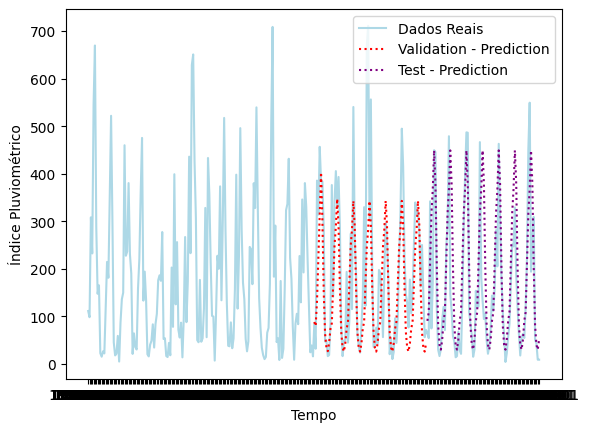

In [ ]:
plot_final_graph(df_pluv_st_filt['value'],df_pluv_st_filt['pred_arima_val'],df_pluv_st_filt['pred_arima_test'])

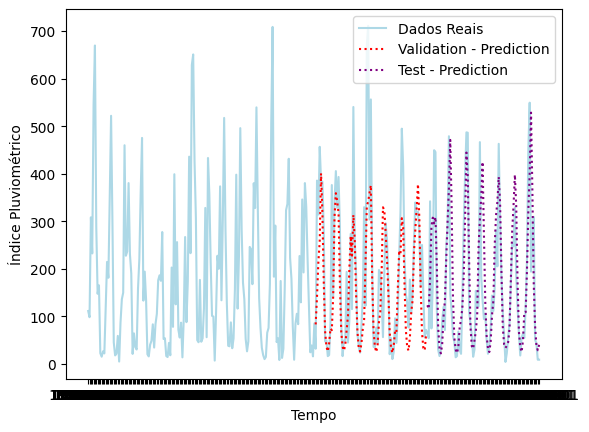

In [ ]:
plot_final_graph(df_pluv_st_filt['value'],result_val_mlp['mlp_final_value_val'],result_test_mlp['mlp_final_value_test'])

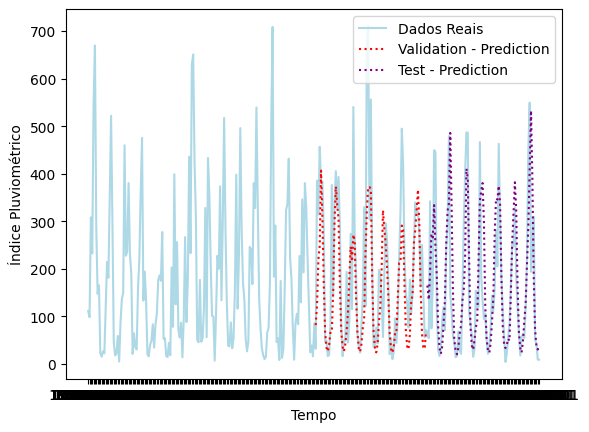

In [ ]:
plot_final_graph(df_pluv_st_filt['value'],result_val_lstm['lstm_final_value_val'],result_test_lstm['lstm_final_value_test'])

- Os gráficos confirmam a ideia de que o modelo LSTM se adaptou melhor aos dados reais, principalmente no conjunto de validação, onde os seus pontos tendem a aproximar mais dos valores reais
- o valor de r² baixo obtido pode estar relacionado ao estilo dos dados apresentados.
  - Neste conjunto de dados se encontram muitos outliears o que dificulta a previsão.